In [1]:
from dataclasses import dataclass
from typing import Any, Optional
import warnings

import pandas as pd
import numpy as np
from scipy import optimize
from scipy import stats
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append("..")
from FluxFox import postproc
from FluxFox.postproc.utils import compute_isday

import numpy as np
import pandas as pd
from tqdm import tqdm

wd = Path(".")
    
cpk = pd.read_parquet(wd / "data" / "cpk.parquet")
float_cols = cpk.select_dtypes(include=["float"]).columns
cpk.loc[:, float_cols] = cpk.loc[:, float_cols].astype("float32")
lat, lon, elev = 41.3966, -106.8024, 2069.0

cpk["rho_a"] = cpk["PA"]*1000 / (287.05 * (cpk["TA"]+273.15))
storage = postproc.compute_single_point_storage_flux(
    cpk,
    rho_col = "rho_a",
    co2_col = "CO2",
    h2o_col = "H2O",
    t_col = "TA",
    co2_zm = 3.0,
    h2o_zm = 3.0,
    t_zm = 3.0
)
cpk["SC"] = storage["SC"]
cpk["SH2O"] = storage["SH2O"]
cpk["SLE"] = storage["SLE"]
cpk["SH"] = storage["SH"]
cpk["NEE"] = cpk["FC"] + cpk["SC"]  # storage-corrected NEE

raw = cpk.copy()

isday = compute_isday(cpk.index, lat, lon, elev)

# despike
spike_flag = postproc.despike_mad_papale_2006(cpk, isday, list(cpk))
cpk = cpk.where(spike_flag)

despiked = cpk.copy()

# ustar filter
ustar_res = postproc.ustar_papale_2006(cpk, isday, "TA", "USTAR", "NEE", n_ustar_classes=15, plateau_pct = 0.92, n_ta_classes=5)
cpk.loc[~ustar_res.flag, ["NEE", "H", "LE", "FC"]] = np.nan

ustar_filtered = cpk.copy()

# gapfill
gapfill_kwargs = dict(
    ta_col="TA",
    ppfd_col="PPFD_IN",
    vpd_col="VPD_PI",
    tsoil_col="TS_1_1_1",
    swc_col="SWC_1_1_1",
    extra_predictor_cols=["WD"],
    n_missing_allowed=1,
    verbose=True,
    hyper_train_frac=0.13,  # 0.3
    hyper_test_frac=0.05,  # 0.1
    n_bayes_iter=15,  #50
    cv_folds=4,  # 5
)
gapfill_result = postproc.gapfill_xgb_liu_2025(
    cpk, "NEE",
    random_state=8472,
    **gapfill_kwargs
)
cpk.loc[:, "NEE"] = gapfill_result.filled
gapfilled = cpk.copy()

# partition, despike, and gapfill once again
cpk[["GPP", "Reco"]] = postproc.gpp_day_lasslop_2010(
    cpk, isday, "NEE", "TA", "PPFD_IN", "VPD_PI",
    n_best_E0 = 2,
    night_window_width_days = 21,
    num_seasons = 4,
).partitioned[["GPP", "Reco"]]
spike_flag = postproc.despike_mad_papale_2006(cpk, isday, ["GPP", "Reco"])
cpk[["GPP", "Reco"]] = cpk[["GPP", "Reco"]].where(spike_flag[["GPP", "Reco"]])

[xgb_gapfill] 86517 rows total | 57545 target gaps to fill | 22160 rows usable for training | 6812 non-gap rows dropped for excess missing predictors
[xgb_gapfill] hyperparameter search: 2880 train / 1108 test rows, 15 Bayes iterations, 4-fold CV scoring


/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests/../FluxFox/postproc/ustar.py:184: UserWarning: R(U*,TA) = 0.47 > 0.40 for TA class [-1.62, 9.27]. Skipping
  warnings.warn(f"R(U*,TA) = {abs(corr):.2f} > {ustar_ta_corr_cutoff:.2f} for TA class [{ta_group[ta_col].min():.2f}, {ta_group[ta_col].max():.2f}]. Skipping")


[xgb_gapfill] best hyperparameters: {'l2_regularization': 0.0001, 'learning_rate': 0.10971639209458427, 'max_depth': 9, 'max_iter': 449, 'max_leaf_nodes': 25, 'min_samples_leaf': 5}
[xgb_gapfill] held-out hyper_test RMSE: 0.8198
[xgb_gapfill] final model test scores: RMSE=0.6820, R2=0.8725, bias=-0.0101 (n_test=4432)
[xgb_gapfill] refitting final model on all usable rows


/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests/../FluxFox/postproc/gapfill.py:392: UserWarning: [xgb_gapfill] WARNING: 42030 gap rows exceed the n_missing_allowed=1 predictor NaN tolerance and cannot be filled; they remain NaN.
  warnings.warn(msg)
/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests/../FluxFox/postproc/partition.py:284: UserWarning: Setting E0 to 50.0 for 2006, season 1, which is the lower bound. If this happens frequently, consider adjusting your fitting parameters or reviewing the quality of your data.
  warnings.warn(f"Setting E0 to {E0} for {year}, season {season}, which is the lower bound. If this happens frequently, consider adjusting your fitting parameters or reviewing the quality of your data.")
/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests/../FluxFox/postproc/partition.py:277: UserWarning: Not enough successful E0 fits

In [2]:
cols_to_gapfill = ["GPP", "Reco", "H", "LE", "FC", "SC", "SH2O", "SLE", "SH"]
for c in (pbar := tqdm(cols_to_gapfill)):
    pbar.set_description(f"Gapfilling {c}")
    gapfill_kwargs["verbose"] = False
    gapfill_result = postproc.gapfill_xgb_liu_2025(
        cpk, c,
        random_state=sum(ord(char) for char in c),
        **gapfill_kwargs
    )
    cpk.loc[:, c] = gapfill_result.filled

Gapfilling SH: 100%|██████████| 9/9 [04:26<00:00, 29.59s/it]  


In [8]:
"NEE" in cpk

True

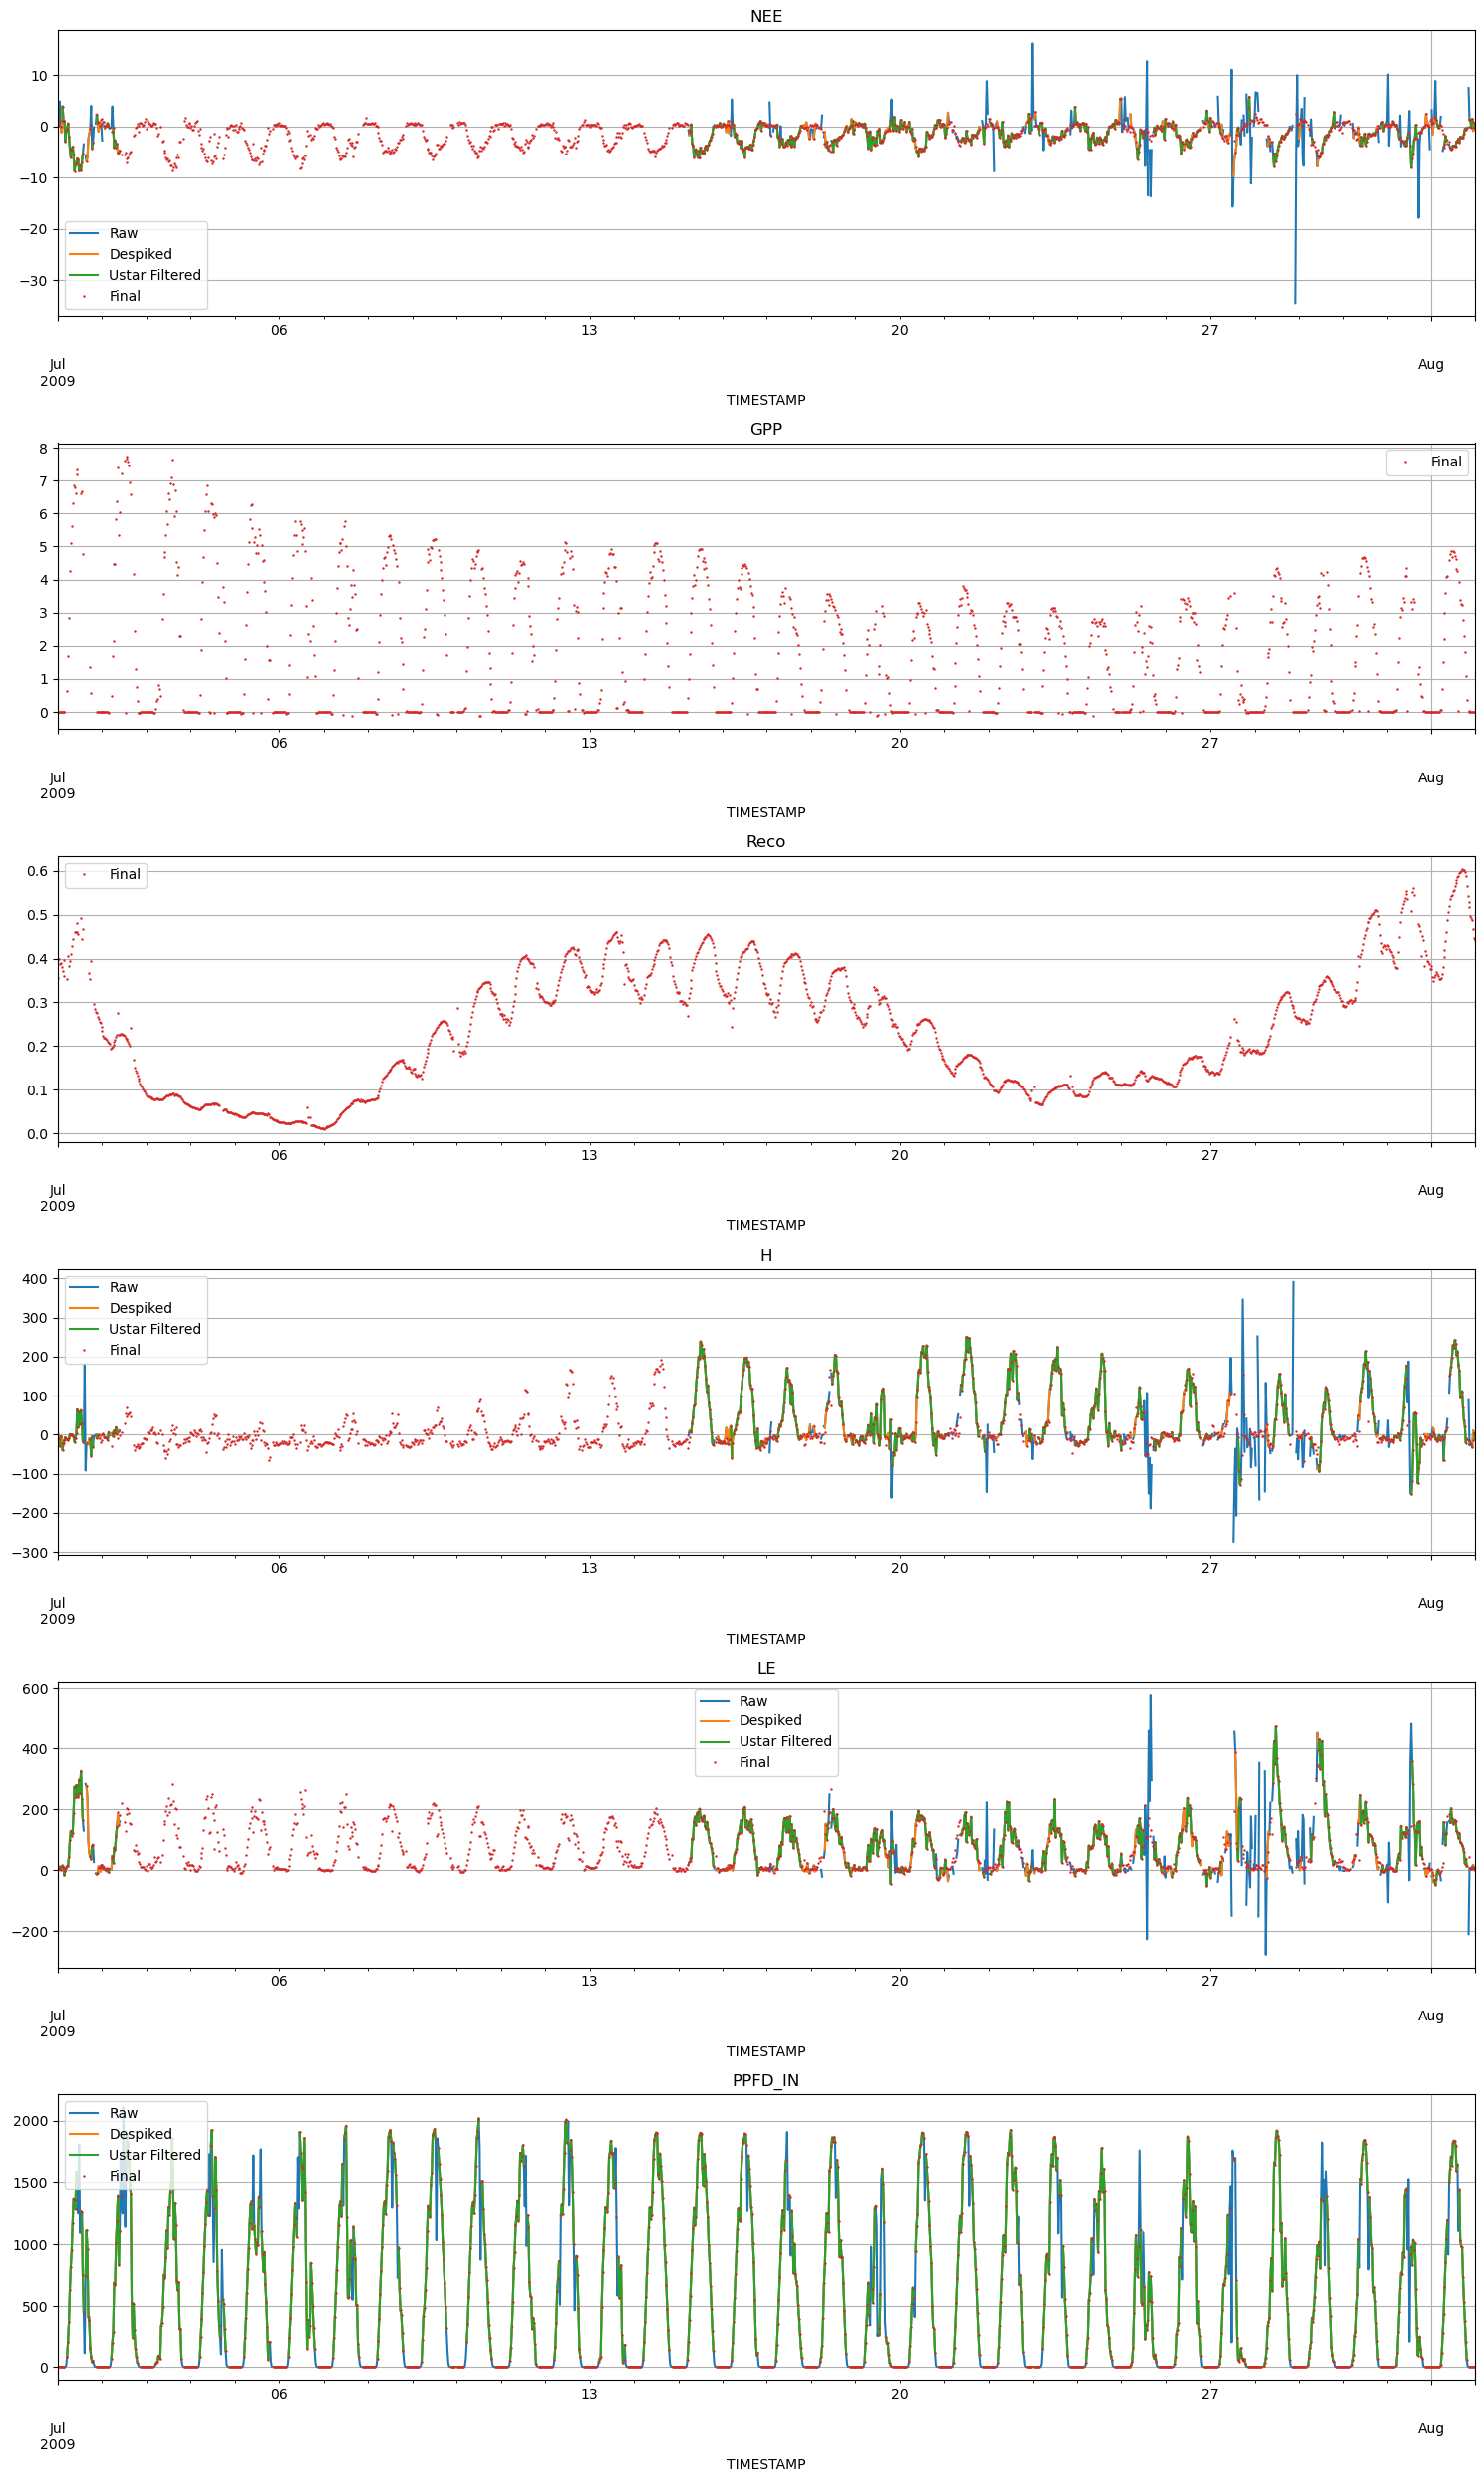

In [14]:
fig, axs = plt.subplots(6, 1, figsize=(15, 25))
start, end = "2009-07-01", "2009-08-01"
for i, col in enumerate(["NEE", "GPP", "Reco", "H", "LE", "PPFD_IN"]):
    if col in raw:
        raw.loc[start:end, col].plot(ax=axs[i], color="C0", label="Raw")
    if col in despiked:
        despiked.loc[start:end, col].plot(label="Despiked", color="C1", ax=axs[i])
    if col in ustar_filtered:
        ustar_filtered.loc[start:end, col].plot(label="Ustar Filtered", color="C2", ax=axs[i])
    if col in cpk:
        cpk.loc[start:end, col].plot(label="Final", style='o', markersize=0.75, color="C3", ax=axs[i])
    axs[i].legend()
    axs[i].set_title(col)
    axs[i].grid(True)
fig.tight_layout()

In [4]:
falge_res = postproc.gpp_night_falge_2001(
    cpk, isday, "NEE", "TA"
)
falge_partition = falge_res.partitioned

reich_res = postproc.gpp_night_reichstein_2005(
    cpk, isday, "NEE", "TA",
    n_best_E0 = 2,
    E0_window_width_days = 21,
    num_seasons = 4,
)
reich_partition = reich_res.partitioned

lasslop_res = postproc.gpp_day_lasslop_2010(
    cpk, isday, "NEE", "TA", "PPFD_IN", "VPD_PI",
    n_best_E0 = 2,
    night_window_width_days = 21,
    num_seasons = 4,
)
lasslop_partition = lasslop_res.partitioned

/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests/../FluxFox/postproc/partition.py:123: UserWarning: Fitted R_ref (0.16839394443113603) or E0 (400.0) are outside expected bounds. Check data quality, fitting parameters, and fitting procedure.
  warnings.warn(f"Fitted R_ref ({R_ref}) or E0 ({E0}) are outside expected bounds. Check data quality, fitting parameters, and fitting procedure.")
/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests/../FluxFox/postproc/partition.py:278: UserWarning: Setting E0 to 50.0 for 2006, season 1, which is the lower bound. If this happens frequently, consider adjusting your fitting parameters or reviewing the quality of your data.
  warnings.warn(f"Setting E0 to {E0} for {year}, season {season}, which is the lower bound. If this happens frequently, consider adjusting your fitting parameters or reviewing the quality of your data.")
/Users/alex/Library/CloudStorage/OneDr

(0.0, 1.0)

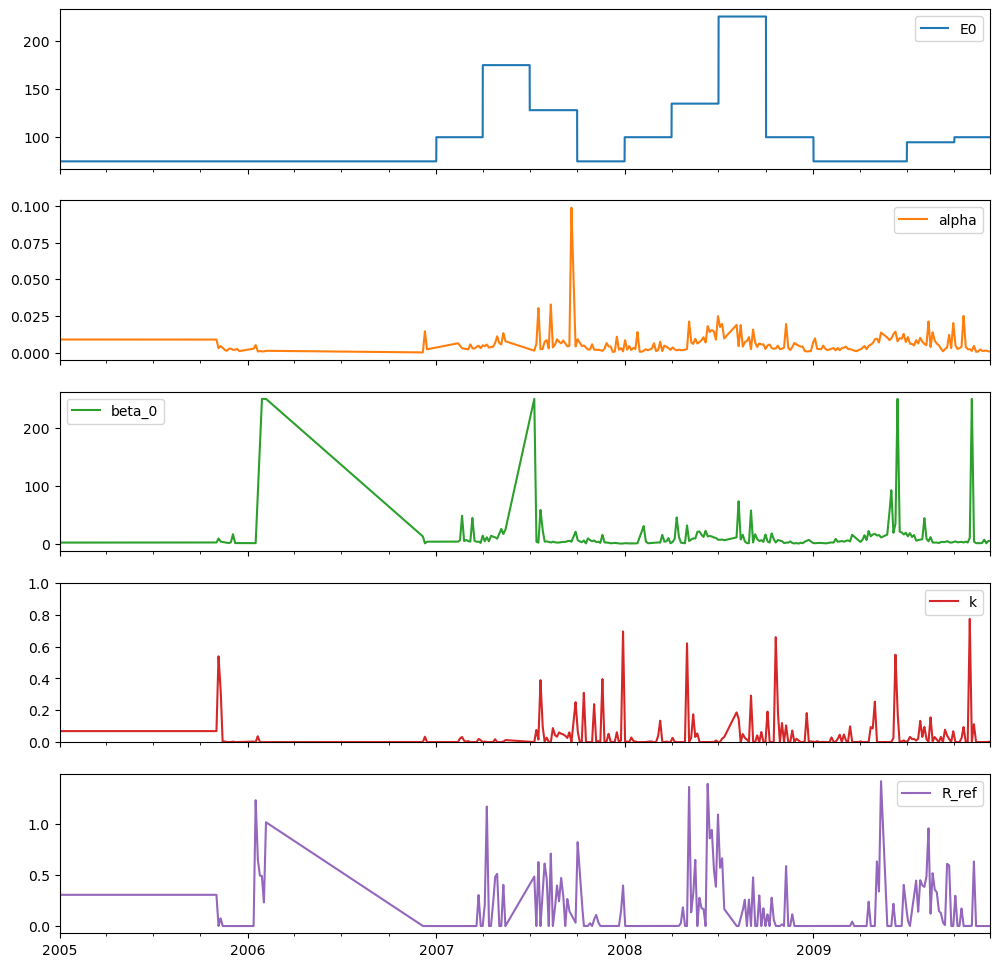

In [5]:
axs = lasslop_res.params.plot(subplots=True, figsize=(12, 12))
axs[-2].set_ylim(0, 1)

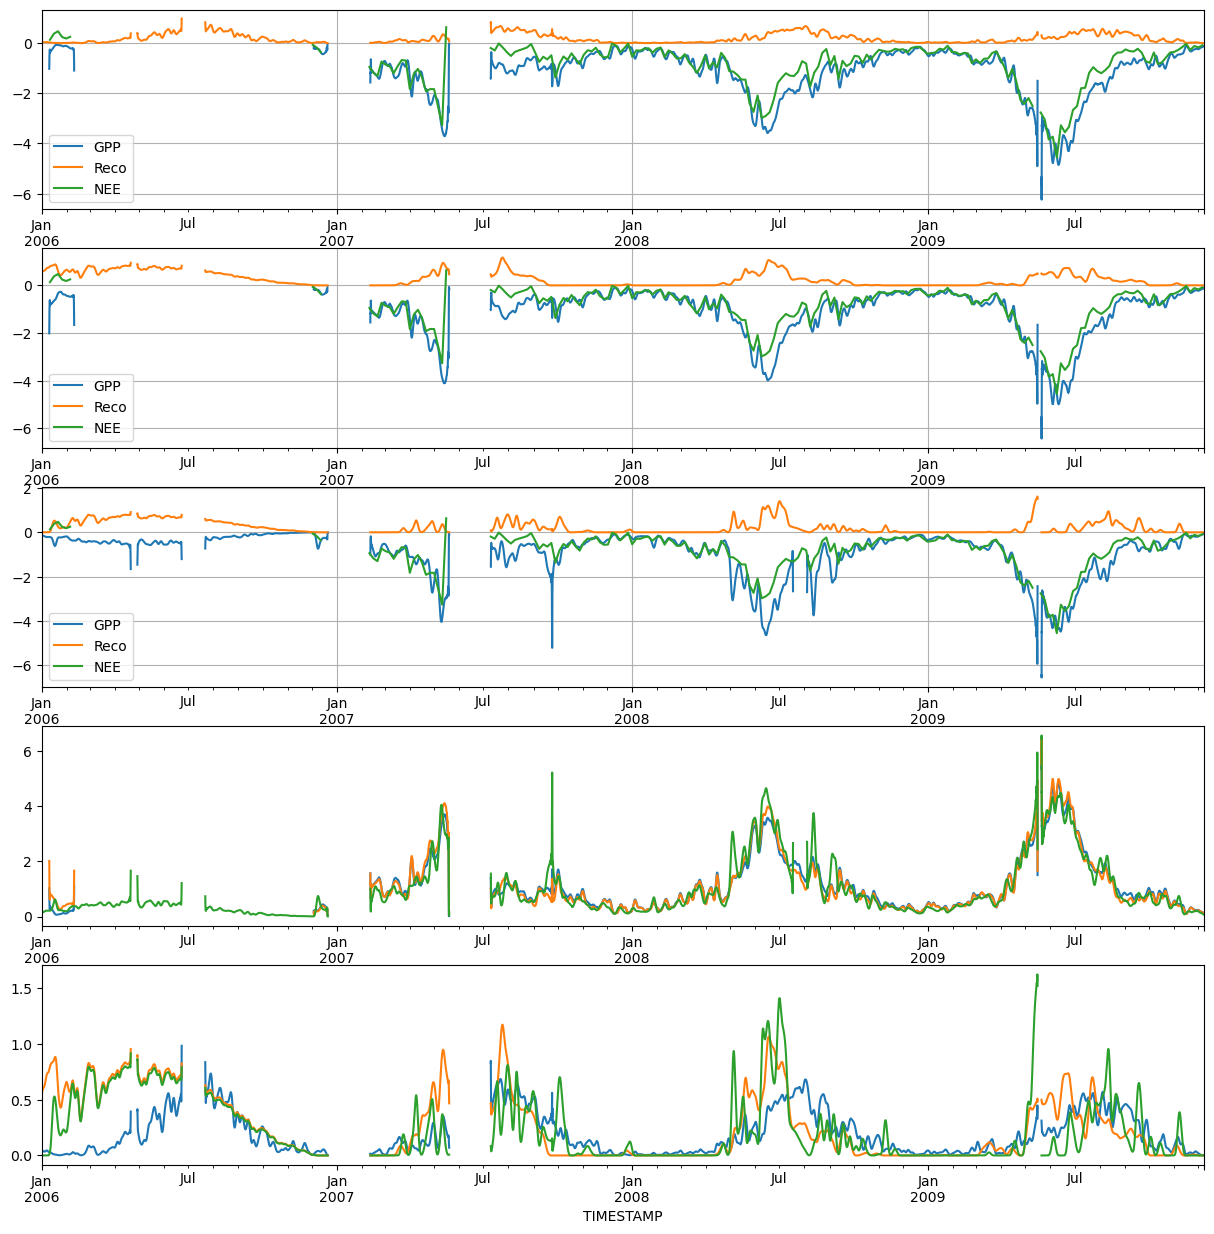

In [6]:
start, end = "2006-01-01", "2009-12-31"
fig, axs = plt.subplots(5, 1, figsize=(15,15))
(falge_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end]*[-1, 1]).plot(ax=axs[0])
(reich_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end]*[-1, 1]).plot(ax=axs[1])
(lasslop_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end]*[-1, 1]).plot(ax=axs[2])
(falge_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "GPP"]).plot(ax=axs[3])
(reich_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "GPP"]).plot(ax=axs[3])
(lasslop_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "GPP"]).plot(ax=axs[3])
(falge_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "Reco"]).plot(ax=axs[4])
(reich_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "Reco"]).plot(ax=axs[4])
(lasslop_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "Reco"]).plot(ax=axs[4])

for ax in axs[:-2]:
    cpk.resample("5d").mean().loc[start:end, "NEE"].plot(label="NEE", ax=ax)
    ax.legend()
    ax.grid()
